In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 
import featuretools as ft
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer


In [3]:
df = pd.read_csv('../data/Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
# Normaliser les noms de diplômes
education_mapping = {
    "high school": "high school",
    "bachelor's": "bachelor's",
    "bachelor's degree": "bachelor's",
    "master's": "master's",
    "master's degree": "master's",
    "phd": "phd",
    "doctorate": "phd",
    None: "unknown"  # Remplacement des NaN par "unknown"
}

df["Education Level"] = df["Education Level"].str.lower().str.strip().map(education_mapping).fillna("unknown")
education_order = ["unknown", "high school", "bachelor's", "master's", "phd"]

education_encoder = OrdinalEncoder(categories=[education_order])
df["Education Level"] = education_encoder.fit_transform(df[["Education Level"]])

job_encoder = LabelEncoder()
df["Job Title"] = job_encoder.fit_transform(df["Job Title"])


gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])

In [5]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,2.0,177,5.0,90000.0
1,28.0,0,3.0,18,3.0,65000.0
2,45.0,1,4.0,145,15.0,150000.0
3,36.0,0,2.0,116,7.0,60000.0
4,52.0,1,3.0,26,20.0,200000.0


In [6]:
#salaire en k
df['Salary'] = df.Salary/1000

In [7]:
df.isna().sum()

Age                    2
Gender                 0
Education Level        0
Job Title              0
Years of Experience    3
Salary                 5
dtype: int64

In [8]:
num_cols = ["Age", "Years of Experience", "Salary"]
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_cols = ["Gender", "Education Level", "Job Title"]
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return r2,rmse

In [11]:
X = df.drop(columns=["Salary"])  
y = df["Salary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [12]:
from sklearn.linear_model import Lasso, Ridge


linearmodel = LinearRegression()
ridgemodel = Ridge(alpha=1.0)
lassomodel = Lasso(alpha=1.0)


r2,rmse = evaluate_model(linearmodel, X_train, y_train, X_test, y_test)
r2_ridge,rmse_ridge = evaluate_model(ridgemodel, X_train, y_train, X_test, y_test)
r2_lasso,rmse_lasso = evaluate_model(lassomodel, X_train, y_train, X_test, y_test)


print(f"Linear Regression - R²: {r2:.2f}, RMSE: {rmse:.2f}")
print(f"Ridge Regression - R²: {r2_ridge:.2f}, RMSE: {rmse_ridge:.2f}")
print(f"Lasso Regression - R²: {r2_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Linear Regression - R²: 0.71, RMSE: 27.96
Ridge Regression - R²: 0.71, RMSE: 27.96
Lasso Regression - R²: 0.70, RMSE: 28.48


In [ ]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Nombre de nouvelles features créées : 42


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [14]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")

Nombre de nouvelles features créées : 42


In [15]:
r2_af,rmse_af = evaluate_model(linearmodel, X_train_af, y_train, X_test_af, y_test)
r2_ridge_af,rmse_ridge_af = evaluate_model(ridgemodel, X_train_af, y_train, X_test_af, y_test)
r2_lasso_af,rmse_lasso_af = evaluate_model(lassomodel, X_train_af, y_train, X_test_af, y_test)

print(f"Linear Regression with AutoFeat - R²: {r2_af:.2f}, RMSE: {rmse_af:.2f}")
print(f"Ridge Regression with AutoFeat - R²: {r2_ridge_af:.2f}, RMSE: {rmse_ridge_af:.2f}")
print(f"Lasso Regression with AutoFeat - R²: {r2_lasso_af:.2f}, RMSE: {rmse_lasso_af:.2f}")

Linear Regression with AutoFeat - R²: 0.81, RMSE: 22.82
Ridge Regression with AutoFeat - R²: 0.81, RMSE: 22.82
Lasso Regression with AutoFeat - R²: 0.80, RMSE: 23.22


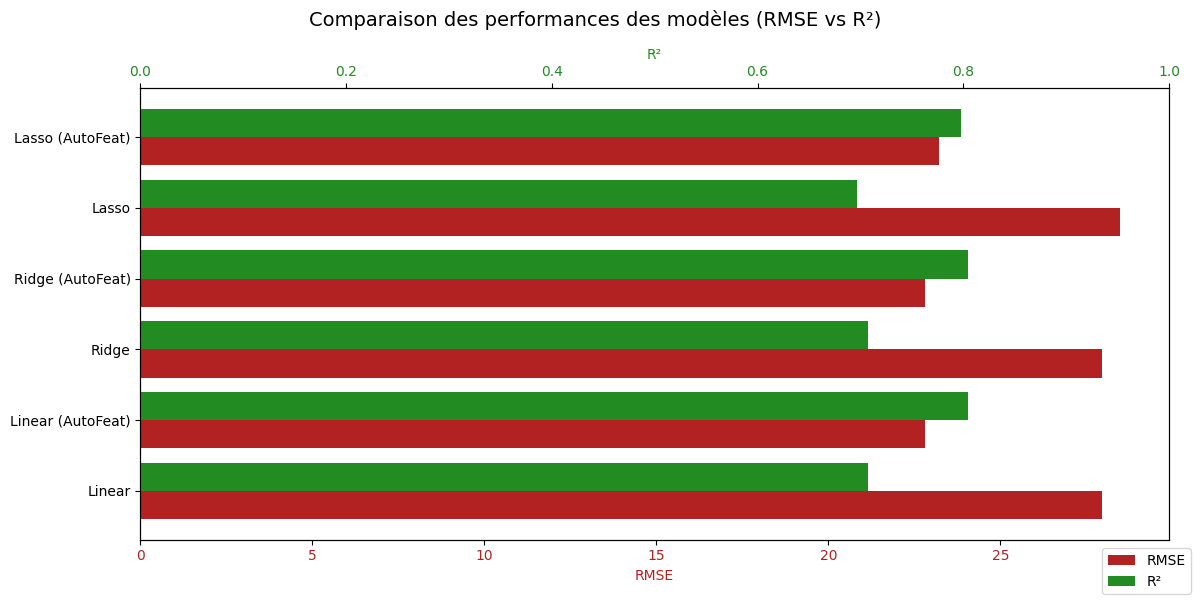

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


model_labels = [
    "Linear", "Linear (AutoFeat)", "Ridge", "Ridge (AutoFeat)", "Lasso", "Lasso (AutoFeat)"
]

rmse_values = [rmse, rmse_af, rmse_ridge, rmse_ridge_af, rmse_lasso, rmse_lasso_af]
r2_values   = [r2,   r2_af,  r2_ridge,  r2_ridge_af,  r2_lasso,  r2_lasso_af]

y = np.arange(len(model_labels))
bar_height = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))


ax1.barh(y - bar_height/2, rmse_values, height=bar_height, color='firebrick', label='RMSE')
ax1.set_xlabel('RMSE', color='firebrick')
ax1.tick_params(axis='x', labelcolor='firebrick')
ax1.set_yticks(y)
ax1.set_yticklabels(model_labels)


ax2 = ax1.twiny()
ax2.barh(y + bar_height/2, r2_values, height=bar_height, color='forestgreen', label='R²')
ax2.set_xlabel('R²', color='forestgreen')
ax2.tick_params(axis='x', labelcolor='forestgreen')
ax2.set_xlim(0, 1)  # R² ∈ [0, 1]


fig.suptitle("Comparaison des performances des modèles (RMSE vs R²)", fontsize=14)
fig.legend(loc="lower right")

plt.tight_layout()
plt.show()
